# Análisis Exploratorio de Datos (EDA)
## Migración internacional a Guatemala, 2009 – junio 2026

**Fuente:** Base de datos de ingreso de viajeros internacionales a Guatemala (uso exclusivamente académico, no son cifras oficiales).

Este notebook cubre:
1. Carga del Excel y conversión a CSV
2. Limpieza básica (valores faltantes / filas producidas por la conversión)
3. Estadísticas descriptivas generales
4. Análisis de duplicados y valores atípicos
5. a) Comportamiento temporal del número de viajeros
6. b) Países con mayor cantidad de viajeros
7. c) Regiones con mayor cantidad de viajeros
8. d) Vías de ingreso y fronteras más utilizadas
9. Conclusiones

> **Nota metodológica importante (ver hoja "Notas" del archivo original):** la base combina tres fuentes con distinta metodología: 2009-2020 (respaldos históricos), 2021-2022 (entrega IGM) y 2023-jun 2026 (sistema depurado INGUAT). Existe un **quiebre metodológico 2022→2023**: la categoría *Viajero* (trabajadores/tránsito fronterizo, NO turistas) cae de ~1.06M a ~0.33M por reclasificación. Para analizar *visitantes* de forma comparable en el tiempo se recomienda usar **Turista + Excursionista**, excluyendo *Viajero* (no es visitante) y *Cruceristas* (solo existe hasta 2022). Esta distinción se respeta a lo largo del análisis.


## 1. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')


## 2. Carga del archivo Excel y transformación a CSV

Se carga la hoja `Datos` del Excel original y se exporta a `.csv` para continuar el flujo de trabajo en ese formato, tal como pide el enunciado.

In [2]:
RUTA_XLSX = "Laboratorio_1__Series_de_Tiempo_2026_-_Base_Migracion_2009-2026jun.xlsx"
RUTA_CSV  = "migracion_guatemala_2009_2026.csv"

df_raw = pd.read_excel(RUTA_XLSX, sheet_name="Datos")
print(f"Filas leídas del Excel: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}")

df_raw.to_csv(RUTA_CSV, index=False, encoding="utf-8-sig")
print(f"Archivo CSV generado: {RUTA_CSV}")


Filas leídas del Excel: 161,036  |  Columnas: 13


Archivo CSV generado: migracion_guatemala_2009_2026.csv


In [3]:
# Releemos desde el CSV para verificar que la conversión no alteró ni filas ni columnas
df = pd.read_csv(RUTA_CSV, encoding="utf-8-sig")
print(f"Filas leídas del CSV: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print("¿Mismo número de filas Excel vs CSV?:", df.shape[0] == df_raw.shape[0])
print("¿Mismas columnas?:", list(df.columns) == list(df_raw.columns))
df.head()


Filas leídas del CSV: 161,036  |  Columnas: 13
¿Mismo número de filas Excel vs CSV?: True
¿Mismas columnas?: True


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


## 3. Limpieza: filas/columnas faltantes provocadas por la conversión

Verificamos si la conversión Excel → CSV introdujo:
- Columnas totalmente vacías
- Filas totalmente vacías (blancas) — típico artefacto de exportación de Excel
- Cambios de tipo de dato (por ejemplo columnas numéricas leídas como texto)


In [4]:
# Filas completamente vacías
filas_vacias = df.isnull().all(axis=1).sum()
print(f"Filas completamente vacías: {filas_vacias}")

# Columnas completamente vacías
cols_vacias = df.columns[df.isnull().all()].tolist()
print(f"Columnas completamente vacías: {cols_vacias if cols_vacias else 'Ninguna'}")

# Tipos de dato por columna
print("\nTipos de dato:")
print(df.dtypes)


Filas completamente vacías: 0
Columnas completamente vacías: Ninguna

Tipos de dato:
Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object


In [5]:
# Eliminamos únicamente filas/columnas 100% vacías si existieran (artefacto de conversión).
# En este archivo no aparecieron, pero se deja el paso por buenas prácticas / reproducibilidad.
antes = df.shape
df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")
print(f"Forma antes: {antes}  ->  Forma después: {df.shape}")
print("No se eliminó ningún registro sustantivo: el dataset se mantiene intacto para el análisis exploratorio.")


Forma antes: (161036, 13)  ->  Forma después: (161036, 13)
No se eliminó ningún registro sustantivo: el dataset se mantiene intacto para el análisis exploratorio.


## 4. Análisis de valores faltantes (missing values)

Revisión columna por columna sobre los datos ya reales (no artefactos de conversión).

In [6]:
faltantes = df.isnull().sum().to_frame("nulos")
faltantes["% del total"] = (faltantes["nulos"] / len(df) * 100).round(3)
faltantes.sort_values("nulos", ascending=False)


,nulos,% del total
Año,0,0.0
Mes cod,0,0.0
Mes,0,0.0
Vía,0,0.0
Frontera,0,0.0
País,0,0.0
Región,0,0.0
Región dos,0,0.0
Regiones OMT,0,0.0
MCEO,0,0.0


**Interpretación:** el dataset no presenta valores faltantes en ninguna columna. Esto es consistente con la nota del proveedor de datos ("sin huecos", 210 meses consecutivos, enero 2009 a junio 2026) y confirma que la fuente ya llega depurada — no fue necesario imputar ni descartar registros.

## 5. Análisis de duplicados

In [7]:
dup_exactos = df.duplicated().sum()
print(f"Filas 100% duplicadas (todas las columnas iguales): {dup_exactos}")

# Duplicados a nivel de "llave" conceptual (mes, vía, frontera, país, tipo de viajero)
llave = ["Año","Mes cod","Vía","Frontera","País","Tipo de Viajero"]
dup_llave = df.duplicated(subset=llave).sum()
print(f"Filas duplicadas por combinación (Año, Mes, Vía, Frontera, País, Tipo de Viajero): {dup_llave}")


Filas 100% duplicadas (todas las columnas iguales): 0
Filas duplicadas por combinación (Año, Mes, Vía, Frontera, País, Tipo de Viajero): 22


**Interpretación:** no existen filas duplicadas, ni exactas ni por la combinación clave del dataset (mes–vía–frontera–país–tipo de viajero). Esto confirma la nota del proveedor: *"formato largo... sin filas de total ni doble conteo"*.

## 6. Estadísticas descriptivas generales

In [8]:
print(f"Rango temporal: {df['Año'].min()} - {df['Año'].max()}  ({df[['Año','Mes cod']].drop_duplicates().shape[0]} meses)")
print(f"Vías de ingreso: {df['Vía'].nunique()}  ->  {df['Vía'].unique().tolist()}")
print(f"Fronteras: {df['Frontera'].nunique()}")
print(f"Países / agrupaciones: {df['País'].nunique()}")
print(f"Tipos de viajero: {df['Tipo de Viajero'].unique().tolist()}")
print()
df["Viajero"].describe()


Rango temporal: 2009 - 2026  (210 meses)
Vías de ingreso: 3  ->  ['Aérea', 'Marítima', 'Terrestre']
Fronteras: 22
Países / agrupaciones: 235
Tipos de viajero: ['Turista', 'Cruceristas', 'Viajero', 'Excursionista']



count   161,036.0
mean        324.7
std       2,387.7
min           0.0
25%           2.0
50%           7.0
75%          38.9
max      92,336.0
Name: Viajero, dtype: float64

In [9]:
df.groupby("Tipo de Viajero")["Viajero"].agg(["count","sum","mean","median","std"]).sort_values("sum", ascending=False)


,count,sum,mean,median,std
Tipo de Viajero,,,,,
Turista,117912,"37,642,728.6",319.2,6.0,"2,611.3"
Excursionista,19730,"9,069,184.3",459.7,10.0,"1,833.7"
Viajero,23190,"4,471,622.2",192.8,8.2,"1,281.2"
Cruceristas,204,"1,104,402.0","5,413.7","4,454.9","4,225.8"


**Interpretación:**
- La variable `Viajero` (personas por fila desagregada) tiene una media muy superior a la mediana (alta asimetría a la derecha): la mayoría de combinaciones país-frontera-mes mueve pocas personas, pero unas pocas combinaciones (p.ej. EE.UU./El Salvador por vía terrestre o aérea) concentran volúmenes enormes.
- El **Turista** es, por lejos, la categoría dominante en número de registros y en volumen acumulado.
- **Cruceristas** aparece con muy pocos registros (204) porque, según la nota metodológica, esta categoría dejó de reportarse en esta base desde 2023.
- Los valores de `Viajero` incluyen decimales porque, conforme a la nota del proveedor, una parte del periodo corresponde a *estimaciones expandidas de encuesta* y no a conteos exactos de frontera.


## 7. Valores atípicos (outliers)

Dado que `Viajero` tiene una distribución fuertemente asimétrica (pocos países/fronteras concentran flujos masivos), usamos el criterio de rango intercuartílico (IQR) para identificarlos, y comparamos con boxplots.

In [10]:
Q1 = df["Viajero"].quantile(0.25)
Q3 = df["Viajero"].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR

outliers = df[df["Viajero"] > lim_sup]
print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  límite superior (Q3+1.5·IQR)={lim_sup:.2f}")
print(f"Registros marcados como atípicos por IQR: {len(outliers):,}  ({len(outliers)/len(df)*100:.1f}% del total)")
outliers.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(10)


Q1=2.00  Q3=38.89  IQR=36.89  límite superior (Q3+1.5·IQR)=94.23
Registros marcados como atípicos por IQR: 26,390  (16.4% del total)


País
El Salvador                 16,164,266.9
Guatemala                   14,725,005.4
Estados Unidos de América    6,958,796.2
Honduras                     2,717,203.4
México                       1,709,153.5
Belice                       1,269,227.7
Nicaragua                    1,101,894.3
Cruceristas                  1,078,287.0
Costa Rica                     827,378.0
Colombia                       513,777.9
Name: Viajero, dtype: float64

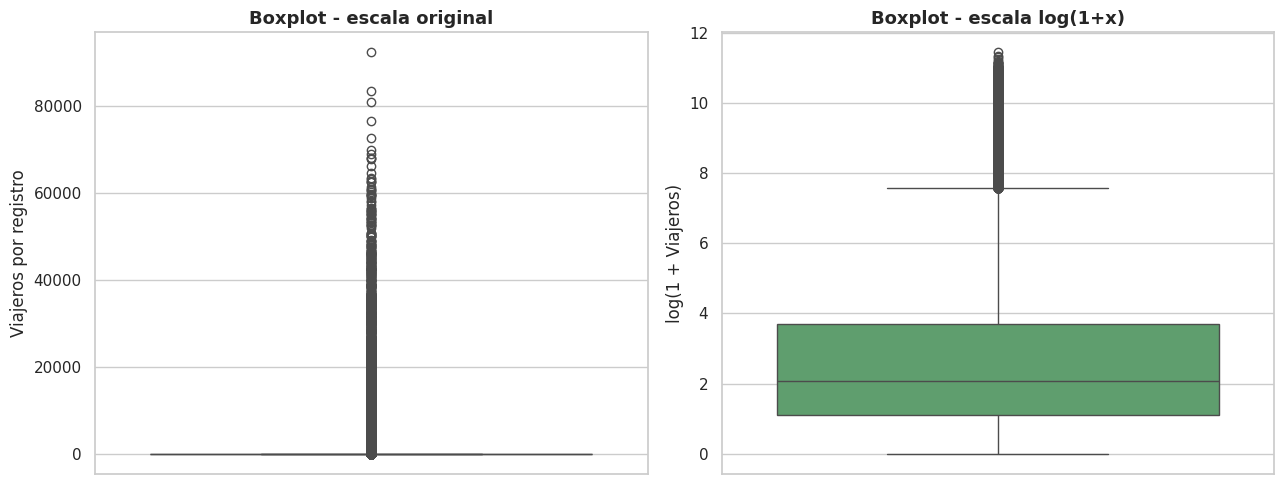

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(y=df["Viajero"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Boxplot - escala original")
axes[0].set_ylabel("Viajeros por registro")

sns.boxplot(y=np.log1p(df["Viajero"]), ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot - escala log(1+x)")
axes[1].set_ylabel("log(1 + Viajeros)")

plt.tight_layout()
plt.savefig("figs/boxplot_outliers.png", dpi=110)
plt.show()


**Interpretación:** con el criterio estadístico de IQR, una proporción importante de registros queda por encima del límite — pero esto **no son errores de captura**, sino la consecuencia natural de una variable de conteo altamente concentrada: pocos países (EE. UU., El Salvador, Honduras, México) y pocas fronteras (La Aurora, Valle Nuevo) explican la mayoría del flujo migratorio, mientras cientos de países pequeños aportan 1-5 personas por mes. El boxplot en escala logarítmica lo confirma: al comprimir la escala, la distribución se ve mucho más simétrica, lo que respalda que se trata de "colas pesadas" propias del fenómeno (concentración geográfica), no de atípicos espurios que deban eliminarse.

## 8. a) Comportamiento temporal del número de viajeros

Se construye la serie mensual y anual usando **Turista + Excursionista** (visitantes comparables en el tiempo, según nota metodológica), y se compara con la serie de "todas las categorías" para evidenciar el quiebre 2022→2023.

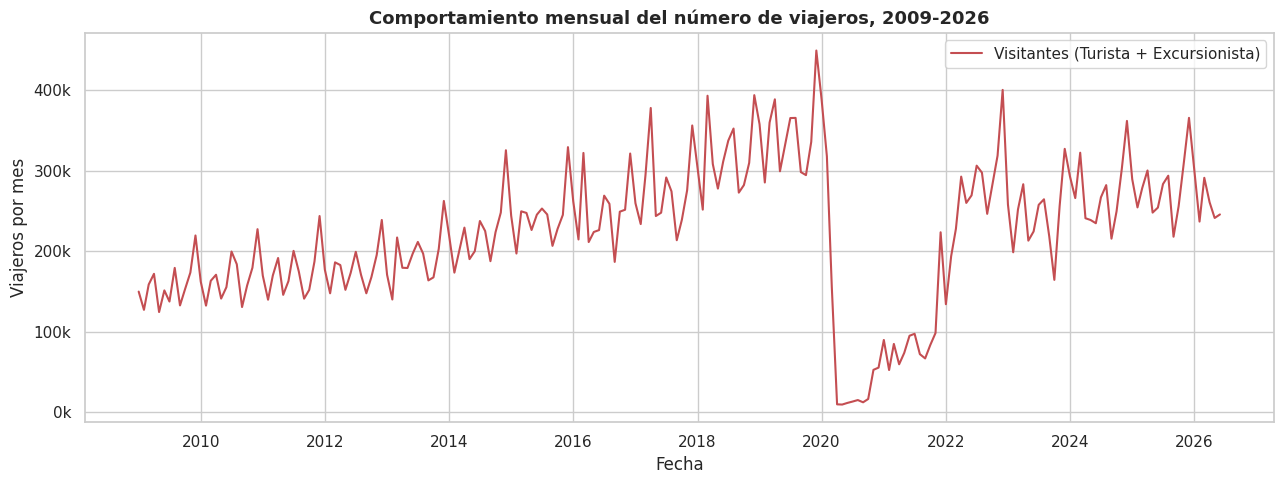

In [12]:
meses_es = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

df["fecha"] = pd.to_datetime(df["Año"].astype(str) + "-" + df["Mes cod"].astype(str) + "-01")

visitantes = df[df["Tipo de Viajero"].isin(["Turista","Excursionista"])]

serie_mensual = visitantes.groupby("fecha")["Viajero"].sum().sort_index()
serie_mensual_todas = df.groupby("fecha")["Viajero"].sum().sort_index()

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(serie_mensual.index, serie_mensual.values, label="Visitantes (Turista + Excursionista)", color="#C44E52")
ax.set_title("Comportamiento mensual del número de viajeros, 2009-2026")
ax.set_ylabel("Viajeros por mes")
ax.set_xlabel("Fecha")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.legend()
plt.tight_layout()
plt.savefig("figs/serie_mensual.png", dpi=110)
plt.show()


**Interpretación:** la serie mensual muestra tendencia creciente de 2009 a 2019, un **colapso abrupto en marzo 2020** (pandemia COVID-19) que lleva el flujo casi a cero durante varios meses, una recuperación gradual desde 2021-2022, y niveles que en 2023-2025 rondan valores similares o superiores a 2018-2019. También se observa estacionalidad recurrente dentro de cada año (picos y valles que se repiten en los mismos meses).

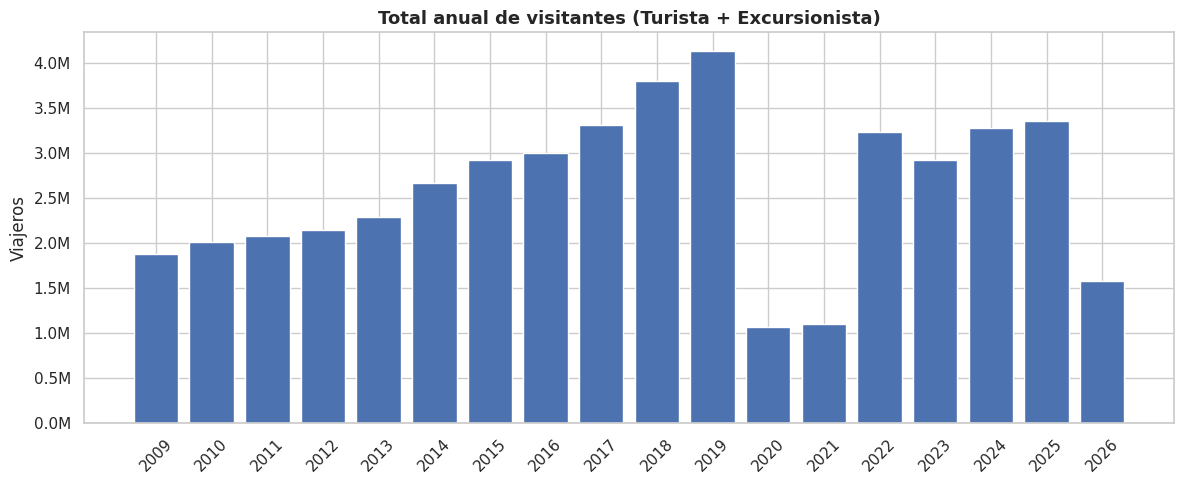

Nota: 2026 solo incluye enero-junio (6 meses), no es comparable directamente con años completos.


Año
2009     NaN
2010     6.6
2011     3.7
2012     2.9
2013     7.0
2014    16.2
2015     9.7
2016     2.7
2017    10.4
2018    14.7
2019     8.9
2020   -74.4
2021     3.7
2022   193.9
2023    -9.6
2024    12.2
2025     2.4
2026   -53.0
Name: Viajero, dtype: float64

In [13]:
serie_anual = visitantes.groupby("Año")["Viajero"].sum()
crecimiento = serie_anual.pct_change() * 100

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(serie_anual.index.astype(str), serie_anual.values, color="#4C72B0")
ax.set_title("Total anual de visitantes (Turista + Excursionista)")
ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figs/serie_anual.png", dpi=110)
plt.show()

print("Nota: 2026 solo incluye enero-junio (6 meses), no es comparable directamente con años completos.")
crecimiento.round(1)


**Interpretación:** el total anual pasó de ~1.9M (2009) a un máximo pre-pandemia de ~4.1M (2019). En 2020 cae a ~1.06M (-74% aprox.) y se mantiene deprimido en 2021. A partir de 2022 se recupera con fuerza y 2023-2025 se estabiliza alrededor de 2.9M-3.4M anuales. **2026 solo cubre enero-junio**, por lo que su cifra (~1.58M) no debe compararse directamente contra años completos sin anualizar.

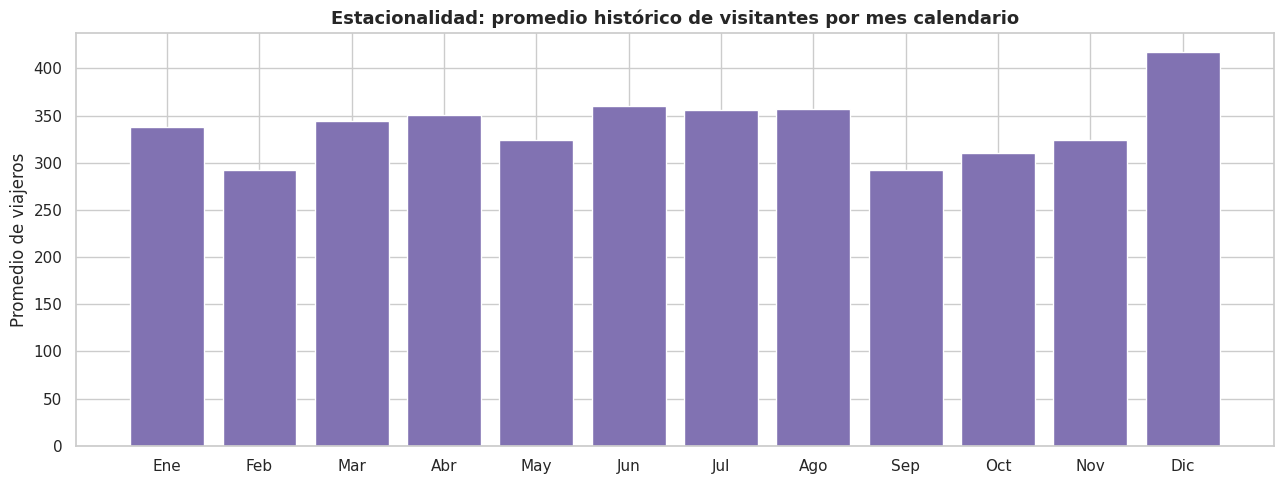

In [14]:
fig, ax = plt.subplots(figsize=(13,5))
prom_mensual = visitantes.groupby("Mes cod")["Viajero"].mean()
ax.bar([meses_es[m] for m in prom_mensual.index], prom_mensual.values, color="#8172B2")
ax.set_title("Estacionalidad: promedio histórico de visitantes por mes calendario")
ax.set_ylabel("Promedio de viajeros")
plt.tight_layout()
plt.savefig("figs/estacionalidad.png", dpi=110)
plt.show()


**Interpretación:** al promediar todos los años por mes calendario se aprecia el patrón estacional típico del turismo receptor: meses de mayor afluencia (vacaciones/festividades) frente a meses de temporada baja. Este patrón es útil para diferenciar estacionalidad "normal" de choques atípicos como la pandemia.

## 9. b) Países con mayor cantidad de viajeros

Se usa nuevamente **Turista + Excursionista** para comparabilidad. Recordar que desde 2023 la columna `País` cambia de granularidad (país individual → agrupación de mercado), lo cual no afecta a los mercados principales analizados aquí.

/tmp/ipykernel_549/2618186242.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, ax=ax, palette="viridis")


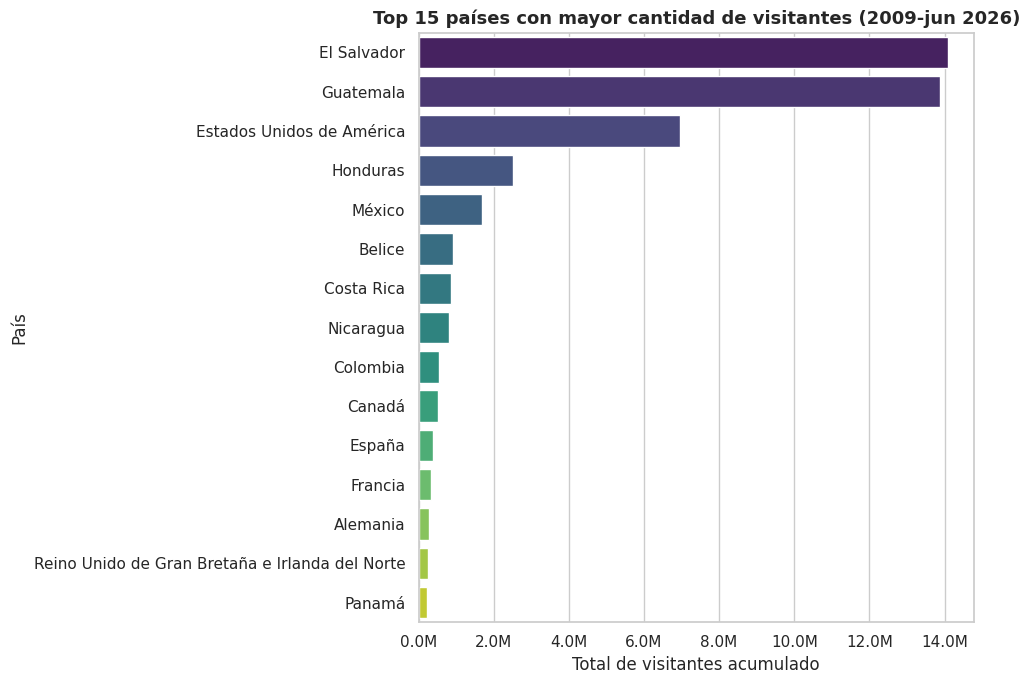

País
El Salvador                                       14,079,135.8
Guatemala                                         13,870,391.3
Estados Unidos de América                          6,965,679.7
Honduras                                           2,520,974.3
México                                             1,678,422.6
Belice                                               916,101.1
Costa Rica                                           860,240.7
Nicaragua                                            811,145.4
Colombia                                             549,494.7
Canadá                                               516,707.9
España                                               388,571.8
Francia                                              329,200.3
Alemania                                             290,773.8
Reino Unido de Gran Bretaña e Irlanda del Norte      259,501.5
Panamá                                               225,943.4
Name: Viajero, dtype: float64

In [15]:
top_paises = visitantes.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10,7))
sns.barplot(x=top_paises.values, y=top_paises.index, ax=ax, palette="viridis")
ax.set_title("Top 15 países con mayor cantidad de visitantes (2009-jun 2026)")
ax.set_xlabel("Total de visitantes acumulado")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.tight_layout()
plt.savefig("figs/top_paises.png", dpi=110)
plt.show()

top_paises


**Interpretación:** el ranking está dominado por **El Salvador**, **Guatemala** (viajeros locales / residentes registrados en el sistema) y **Estados Unidos**, seguidos por **Honduras** y **México** — es decir, la migración/turismo hacia Guatemala es abrumadoramente **regional (Centroamérica y Norteamérica)**. Los mercados extra-regionales (España, Francia, Canadá) aparecen muy por debajo, confirmando que Guatemala recibe sobre todo tránsito y visitantes fronterizos/regionales.

## 10. c) Regiones con mayor cantidad de viajeros

/tmp/ipykernel_549/2740722086.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regiones.values, y=top_regiones.index, ax=ax, palette="mako")


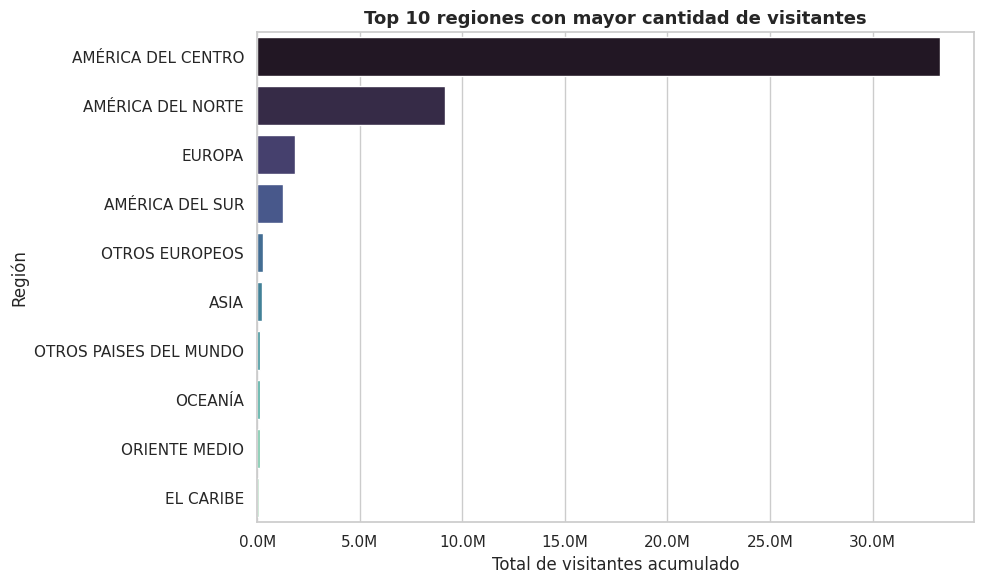

Región
AMÉRICA DEL CENTRO       33,283,932.0
AMÉRICA DEL NORTE         9,160,810.2
EUROPA                    1,848,626.4
AMÉRICA DEL SUR           1,269,401.2
OTROS EUROPEOS              300,644.6
ASIA                        238,747.0
OTROS PAISES DEL MUNDO      149,136.1
OCEANÍA                     130,624.7
ORIENTE MEDIO               126,080.0
EL CARIBE                    75,673.5
Name: Viajero, dtype: float64

In [16]:
top_regiones = visitantes.groupby("Región")["Viajero"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=top_regiones.values, y=top_regiones.index, ax=ax, palette="mako")
ax.set_title("Top 10 regiones con mayor cantidad de visitantes")
ax.set_xlabel("Total de visitantes acumulado")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))
plt.tight_layout()
plt.savefig("figs/top_regiones.png", dpi=110)
plt.show()

top_regiones


**Interpretación:** **América del Centro** concentra la enorme mayoría de los visitantes, seguida a distancia por **América del Norte**. Europa, América del Sur y el resto de regiones representan una fracción menor del total. Esto refuerza el hallazgo anterior: el turismo/tránsito hacia Guatemala es fundamentalmente intrarregional centroamericano.

## 11. d) Vías de ingreso y fronteras más utilizadas

/tmp/ipykernel_549/731332656.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fronteras.values, y=top_fronteras.index, ax=axes[1], palette="crest")


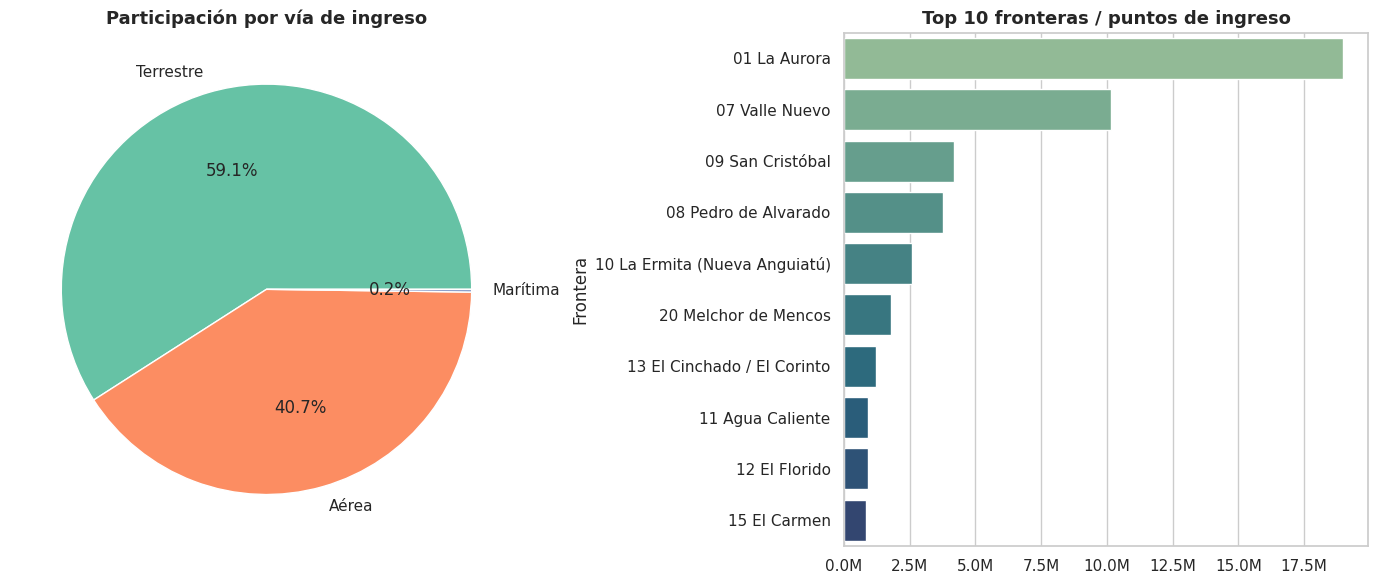

Vía
Terrestre   27,592,253.3
Aérea       19,019,418.6
Marítima       100,241.0
Name: Viajero, dtype: float64

Frontera
01 La Aurora                    18,989,984.6
07 Valle Nuevo                  10,143,045.3
09 San Cristóbal                 4,183,631.7
08 Pedro de Alvarado             3,764,229.3
10 La Ermita (Nueva Anguiatú)    2,587,072.3
20 Melchor de Mencos             1,782,864.4
13 El Cinchado / El Corinto      1,213,485.1
11 Agua Caliente                   922,419.5
12 El Florido                      910,373.5
15 El Carmen                       852,663.1
Name: Viajero, dtype: float64


In [17]:
top_vias = visitantes.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].pie(top_vias.values, labels=top_vias.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[0].set_title("Participación por vía de ingreso")

top_fronteras = visitantes.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_fronteras.values, y=top_fronteras.index, ax=axes[1], palette="crest")
axes[1].set_title("Top 10 fronteras / puntos de ingreso")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f}M"))

plt.tight_layout()
plt.savefig("figs/vias_fronteras.png", dpi=110)
plt.show()

print(top_vias)
print()
print(top_fronteras)


**Interpretación:** la vía **Terrestre** es la más utilizada en volumen total, seguida de cerca por la **Aérea**; la vía **Marítima** es marginal (y, según la nota metodológica, pierde detalle de registro desde 2017, por lo que su peso real podría estar subestimado en años recientes). Entre las fronteras, **La Aurora** (aeropuerto principal) y **Valle Nuevo** (frontera terrestre con El Salvador) concentran la mayor parte del flujo, coherente con el dominio de El Salvador y EE. UU. como principales orígenes.

## 12. Conclusiones del análisis exploratorio

1. **Calidad de datos:** el archivo no presenta valores faltantes ni duplicados; la conversión Excel→CSV no introdujo filas/columnas vacías. Es una base ya depurada por la fuente.
2. **Valores atípicos:** los "outliers" detectados por IQR corresponden a la concentración geográfica natural del fenómeno (pocos países/fronteras explican la mayoría del flujo), no a errores de captura.
3. **Comportamiento temporal:** tendencia creciente 2009-2019, colapso por la pandemia en 2020-2021, recuperación desde 2022 y estabilización 2023-2025 en niveles cercanos a 2018-2019. 2026 solo tiene 6 meses de datos.
4. **Países:** El Salvador, Guatemala, Estados Unidos, Honduras y México concentran la gran mayoría de los visitantes.
5. **Regiones:** América Central y América del Norte dominan ampliamente sobre el resto del mundo.
6. **Vías/fronteras:** Terrestre y Aérea son las vías dominantes; La Aurora y Valle Nuevo son los puntos de ingreso más utilizados.
7. **Advertencia metodológica:** cualquier comparación 2022 vs. 2023 en adelante debe hacerse con cautela por el cambio de fuente/metodología documentado por el proveedor de los datos (usar Turista+Excursionista, no "Viajero" ni "Cruceristas").
